<a href="https://colab.research.google.com/github/Tejaswimadastu/Deep_Learning/blob/main/IMDB_Dataset_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Business Scenario**

A large e-commerce company receives thousands of product reviews every day.
Management wants an AI system that can automatically detect whether a review is positive or negative, so they can:

1. Highlight positive reviews
2. Detect negative customer experiences early
3. Improve product quality

You are hired as a Data Scientist to build a Deep Learning model using Recurrent Neural Networks (RNN) to analyze the review text and predict sentiment.

Column	Description

review	Text review

sentiment	positive / negative


# Task 1 — Understand the Business Problem

You must first analyze the problem before coding.

**Tasks:**

Explain why text reviews are sequential data

Explain why traditional ML models struggle with sequence understanding

Justify why RNN is suitable for this problem

Expected explanation should include:

order of words matters

contextual meaning

sequential memory


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

In [2]:
from google.colab import files
uploaded = files.upload()
import pandas as pd

Saving IMDB_Dataset.csv to IMDB_Dataset.csv


In [3]:
df = pd.read_csv("IMDB_Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'], test_size=0.2, random_state=42
)

In [6]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [7]:
max_len = 200

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [8]:
model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=max_len),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [9]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train model

In [10]:
model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 82ms/step - accuracy: 0.7078 - loss: 0.5495 - val_accuracy: 0.8267 - val_loss: 0.4025
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step - accuracy: 0.8452 - loss: 0.3623 - val_accuracy: 0.8322 - val_loss: 0.3901
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.8922 - loss: 0.2655 - val_accuracy: 0.8418 - val_loss: 0.4210
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 65ms/step - accuracy: 0.9234 - loss: 0.1972 - val_accuracy: 0.8316 - val_loss: 0.4952
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 34s 68ms/step - accuracy: 0.9128 - loss: 0.2238 - val_accuracy: 0.8257 - val_loss: 0.4242


**Evaluate**

In [11]:
loss, acc = model.evaluate(X_test_pad, y_test)
print("Loss:", loss)
print("Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.8323 - loss: 0.4119
Loss: 0.41185781359672546
Accuracy: 0.8323000073432922


In [12]:
pred = model.predict(X_test_pad)
pred = (pred > 0.5).astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


In [13]:
sample = ["This product is amazing and works perfectly"]

sample_seq = tokenizer.texts_to_sequences(sample)
sample_pad = pad_sequences(sample_seq, maxlen=max_len)

result = model.predict(sample_pad)

print("Positive" if result > 0.5 else "Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Positive


# Task 2 — Data Exploration
Students should explore the dataset.

Tasks:

1. Load the dataset
2. Check dataset size
3. Count positive vs negative reviews
4. Display sample reviews
5. Calculate average review length

**Check:**

Are reviews balanced?

Are reviews long or short?

In [14]:
df.shape

(50000, 2)

**Count of positive vs negative reviews**

In [15]:
df['sentiment'].value_counts()

,count
sentiment,
1,25000
0,25000


In [16]:
df['review'].head(5)

,review
0,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...
2,I thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is..."


In [17]:
df['length'] = df['review'].apply(lambda x: len(x.split()))
df['length'].head()

,length
0,307
1,162
2,166
3,138
4,230


In [18]:
df['length'].mean()

np.float64(231.15694)

**Sample reviews**

In [19]:
df['sentiment'].value_counts(normalize=True)

,proportion
sentiment,
1,0.5
0,0.5


**Average review length**

In [20]:
df['length'].describe()

,length
count,50000.000000
mean,231.156940
std,171.343997
min,4.000000
25%,126.000000
50%,173.000000
75%,280.000000
max,2470.000000


# Task 3 — Text Preprocessing

Raw text cannot be fed directly into neural networks.

You must perform preprocessing:

Tasks:

1. Convert text to lowercase
2. Remove punctuation
3. Remove HTML tags
4. Tokenize words
5. Remove stopwords
6. Convert words → sequences

Expected output example:

Original:

"This movie was absolutely fantastic!"
Processed:

["movie", "absolutely", "fantastic"]


In [21]:
import re
import nltk

nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [22]:
stop_words = set(stopwords.words('english'))

**Text Cleaning Function**

In [23]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return words

In [24]:
df['processed'] = df['review'].apply(preprocess)

In [25]:
df[['review', 'processed']].head()

,review,processed
0,One of the other reviewers has mentioned that ...,"[one, reviewers, mentioned, watching, 1, oz, e..."
1,A wonderful little production. <br /><br />The...,"[wonderful, little, production, filming, techn..."
2,I thought this was a wonderful way to spend ti...,"[thought, wonderful, way, spend, time, hot, su..."
3,Basically there's a family where a little boy ...,"[basically, theres, family, little, boy, jake,..."
4,"Petter Mattei's ""Love in the Time of Money"" is...","[petter, matteis, love, time, money, visually,..."


In [26]:
df['processed_text'] = df['processed'].apply(lambda x: " ".join(x))

# Tokenization

In [27]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['processed_text'])

sequences = tokenizer.texts_to_sequences(df['processed_text'])

In [28]:
print(df['review'][0])
print(df['processed'][0])
print(sequences[0])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

# Task 4 — Tokenization and Vocabulary Building
You must convert words into numerical representations.

**Tasks:**

1. Use Keras Tokenizer
2. Create vocabulary
3. Convert reviews → sequences
4. Display word index mapping

Example:

Word	Index

movie	1

good	2

bad	3

Check:

Why neural networks cannot process raw text directly?




In [29]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [30]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['processed_text'])

In [31]:
word_index = tokenizer.word_index
print(dict(list(word_index.items())[:10]))

{'movie': 1, 'film': 2, 'one': 3, 'like': 4, 'good': 5, 'even': 6, 'would': 7, 'time': 8, 'really': 9, 'see': 10}


In [32]:
sequences = tokenizer.texts_to_sequences(df['processed_text'])
print(sequences[0])

[3, 1808, 940, 56, 396, 3206, 286, 349, 3024, 107, 481, 470, 19, 57, 3096, 3206, 50, 472, 180, 107, 548, 52, 1604, 41, 41, 2357, 1338, 276, 472, 3258, 246, 233, 353, 3206, 240, 2417, 938, 2481, 1246, 421, 4556, 2374, 1080, 2829, 298, 215, 4901, 3548, 421, 236, 4987, 2317, 224, 34, 126, 7, 45, 166, 1172, 41, 550, 91, 159, 154, 435, 2842, 703, 84, 1144, 4164, 2352, 974, 703, 1281, 703, 58, 852, 87, 19, 286, 43, 104, 3096, 1450, 2066, 287, 45, 1421, 174, 1335, 1121, 3206, 88, 215, 1948, 1960, 472, 472, 4783, 2797, 379, 499, 14, 140, 13, 632, 693, 542, 1080, 550, 438, 806, 1859, 1080, 443, 56, 3206, 98, 302, 3601, 3114, 14, 1082, 3861, 391]


In [33]:
print("Vocab Size:", len(word_index))

Vocab Size: 221756


# Task 5 — Sequence Padding
RNN requires fixed-length input sequences.

Tasks:

Find maximum review length

Apply padding using pad_sequences()

Compare before and after padding

Example:

1. Before padding
[12, 45, 67]
2. After padding
[0,0,0,12,45,67]

You must explain:

Why padding is necessary for RNN models.




**Max review length**

In [34]:
max_len = max(len(seq) for seq in sequences)
print("Max Length:", max_len)

Max Length: 885


In [35]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

padded = pad_sequences(sequences, maxlen=max_len, padding='pre')

In [36]:
print("Before:", sequences[0])
print("After :", padded[0])

Before: [3, 1808, 940, 56, 396, 3206, 286, 349, 3024, 107, 481, 470, 19, 57, 3096, 3206, 50, 472, 180, 107, 548, 52, 1604, 41, 41, 2357, 1338, 276, 472, 3258, 246, 233, 353, 3206, 240, 2417, 938, 2481, 1246, 421, 4556, 2374, 1080, 2829, 298, 215, 4901, 3548, 421, 236, 4987, 2317, 224, 34, 126, 7, 45, 166, 1172, 41, 550, 91, 159, 154, 435, 2842, 703, 84, 1144, 4164, 2352, 974, 703, 1281, 703, 58, 852, 87, 19, 286, 43, 104, 3096, 1450, 2066, 287, 45, 1421, 174, 1335, 1121, 3206, 88, 215, 1948, 1960, 472, 472, 4783, 2797, 379, 499, 14, 140, 13, 632, 693, 542, 1080, 550, 438, 806, 1859, 1080, 443, 56, 3206, 98, 302, 3601, 3114, 14, 1082, 3861, 391]
After : [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0

In [37]:
# Before
[12, 45, 67]

# After (max_len = 6)
[0, 0, 0, 12, 45, 67]

[0, 0, 0, 12, 45, 67]

# Task 6 — Build an RNN Model
You must implement a simple RNN architecture.

Architecture example:

1. Embedding Layer
2. SimpleRNN Layer
3. Dense Layer
4. Output Layer

**Tasks:**

1. Define embedding layer
2. Add SimpleRNN layer
3. Add dense output layer
3. Compile model

Students must print:

model.summary()


In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

**Define model**

In [39]:
vocab_size = 5000
embedding_dim = 64
max_len = padded.shape[1]

model = Sequential()

**Embedding layer**

In [40]:
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


**SimpleRNN Layer**

In [41]:
model.add(SimpleRNN(64))

In [42]:
model.add(Dense(1, activation='sigmoid'))

In [43]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [44]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Task 7 — Train the RNN Model
You must train the model.

Tasks:

1. Split dataset into train/test
2. Train the RNN model
3. Plot training accuracy
4. Plot validation accuracy

You must analyze:

Is the model overfitting?

Is accuracy improving?


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    padded, df['sentiment'], test_size=0.2, random_state=42
)

In [46]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 202s 317ms/step - accuracy: 0.7218 - loss: 0.5256 - val_accuracy: 0.8381 - val_loss: 0.3805
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 189s 302ms/step - accuracy: 0.8547 - loss: 0.3514 - val_accuracy: 0.8537 - val_loss: 0.3515
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 223s 357ms/step - accuracy: 0.8668 - loss: 0.3243 - val_accuracy: 0.8422 - val_loss: 0.3670
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 199s 319ms/step - accuracy: 0.8694 - loss: 0.3193 - val_accuracy: 0.8367 - val_loss: 0.3885
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 205s 327ms/step - accuracy: 0.8820 - loss: 0.2947 - val_accuracy: 0.8419 - val_loss: 0.3820


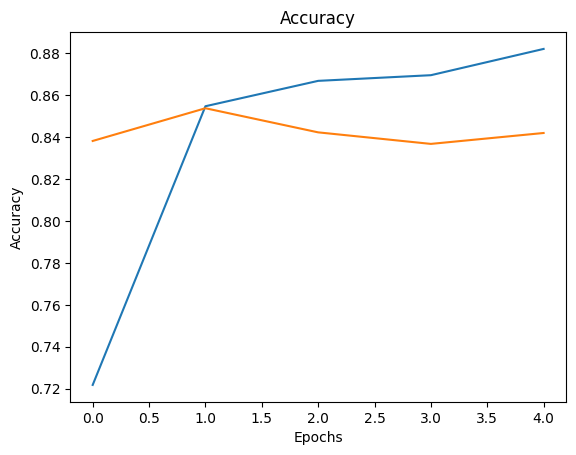

In [48]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

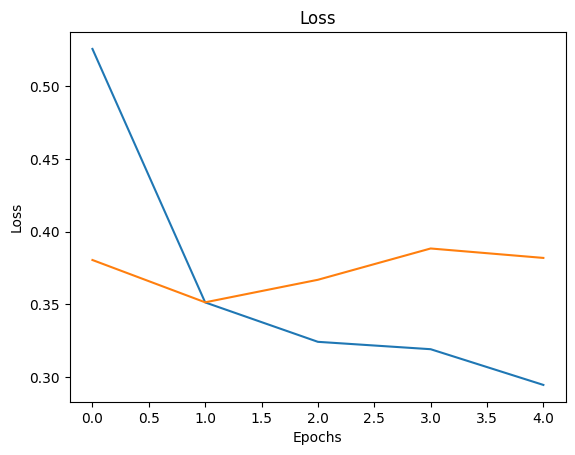

In [49]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# Task 8 — Evaluate Model Performance
You must evaluate the trained model.

Tasks:

1. Calculate accuracy
2. Generate confusion matrix
3. Compute precision and recall
4. Analyze misclassified reviews

You must interpret:

Which type of reviews are harder to classify?

In [50]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step


In [51]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.8419


In [52]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[4115  846]
 [ 735 4304]]


In [53]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.8357281553398058
Recall: 0.854137725739234


In [54]:
mis_idx = [i for i in range(len(y_test)) if y_test.iloc[i] != y_pred[i]]

for i in mis_idx[:5]:
    print("Review:", df['review'].iloc[i])
    print("Actual:", y_test.iloc[i], "Predicted:", y_pred[i])
    print("-----")

Review: A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well

# Task 9 — Real-Time Prediction System
You must build a custom review prediction function.

Example:

1. Input:
"This product quality is amazing"
2. Expected Output:
Predicted Sentiment → Positive

Confidence → 0.92

You must test at least 5 custom reviews.


In [55]:
def predict_review(text):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_len)

    prob = model.predict(pad)[0][0]

    sentiment = "Positive" if prob > 0.5 else "Negative"

    return sentiment, prob

In [56]:
reviews = [
    "This product quality is amazing",
    "Worst experience ever",
    "Not bad but could be better",
    "Absolutely loved it",
    "Waste of money"
]

for r in reviews:
    sentiment, prob = predict_review(r)
    print("Review:", r)
    print("Predicted:", sentiment)
    print("Confidence:", round(prob, 2))
    print("------")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
Review: This product quality is amazing
Predicted: Positive
Confidence: 0.99
------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
Review: Worst experience ever
Predicted: Positive
Confidence: 0.92
------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
Review: Not bad but could be better
Predicted: Positive
Confidence: 0.9
------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
Review: Absolutely loved it
Predicted: Positive
Confidence: 1.0
------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
Review: Waste of money
Predicted: Negative
Confidence: 0.33
------
